# 股票涨跌预测建模

依据 `stock_ml_prediction_spec.md` 执行：数据获取(模块1) → 探查(模块2) → 预处理(模块3) → 三段切分(模块4) → 训练调参(模块5) → 最终评估对比(模块6)。

**Notebook 组织**：公共区 + 评估函数 + 各模型调参单元(可反复运行) + 实验日志 + 最终对比区(仅最后运行一次)。
**关键纪律**：
- 预处理统计量仅在训练集拟合
- 调参只用验证集，**测试集只在最终对比区评估一次**
- 切分严格按时间(禁止随机)

## 模块 1：数据获取与说明

### 公共区：导入、绘图、字体

In [45]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# macOS 中文字体规范
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# 模型与评估
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay)
from lightgbm import LGBMClassifier

# 随机种子与常量
SEED = 42
np.random.seed(SEED)

print(f'matplotlib: {matplotlib.__version__}  |  字体: {matplotlib.rcParams["font.sans-serif"]}')
print('环境就绪')

matplotlib: 3.9.4  |  字体: ['Arial Unicode MS', 'SimHei', 'Microsoft YaHei']
环境就绪


### 1.1 数据加载

In [46]:
df = pd.read_csv('../data/model_data_stock.csv', dtype={'Code': str})
df['Date'] = pd.to_datetime(df['Date'])
print(f'数据形状: {df.shape}')
print(f'期数: {sorted(df["Date"].unique())}')
df.head()

数据形状: (20772, 20)
期数: [Timestamp('2021-06-30 00:00:00'), Timestamp('2021-09-30 00:00:00'), Timestamp('2021-12-31 00:00:00'), Timestamp('2022-03-31 00:00:00'), Timestamp('2022-06-30 00:00:00')]


,Date,Code,企业倍数(EV除EBITDA),市净率PB(MRQ),市现率PCF(现金净流量TTM),市现率PCF(经营现金流TTM),市盈率PE(TTM),"市盈率PE(TTM,扣除非经常性损益)",市销率PS(TTM),股息率(近12个月),MV,净利润同比增长率,净资产同比增长率,利润总额(同比增长率),基本每股收益(同比增长率),总资产同比增长率,现金净流量同比增长率,营业利润(同比增长率),营业总收入(同比增长率),Y
0,2021-06-30,000001,178.031265,1.450284,4.158766,-9.604662,14.386532,14.418192,2.788759,0.795756,4389.618696,28.549496,7.340985,27.0313,21.212121,13.040136,3.065010,26.9324,8.1095,False
1,2021-06-30,000002,4.087263,1.225560,12.789059,3.788184,6.656121,6.850769,0.637955,4.269690,2698.195472,-13.181867,13.417901,-16.5199,-14.414414,8.241644,-95.340285,-17.2279,14.1862,False
2,2021-06-30,000004,43.451859,2.096619,46.748413,1845.349234,47.051819,48.211020,10.426417,0.680641,30.633767,193.215436,4.885155,93.9522,136.538462,5.093304,-3.498717,92.2387,73.9161,True
3,2021-06-30,000005,-6.016503,1.594176,-140.760010,33.437268,-5.557283,-4.482084,4.958022,0.987982,19.900493,673.411428,-11.424587,701.1840,700.657895,-18.248636,48.889779,120.7927,22.7985,True
4,2021-06-30,000006,8.856827,0.885989,7.312974,17.339335,6.722733,7.026851,2.113051,3.852295,67.634752,75.185870,11.547872,65.4533,78.460583,25.341466,-14.232979,60.0630,22.6193,False


### 1.2 字段清单与标签定义

**估值/规模因子(9)**: 企业倍数(EV除EBITDA)、市净率PB(MRQ)、市现率PCF(现金净流量TTM)、市现率PCF(经营现金流TTM)、市盈率PE(TTM)、市盈率PE(TTM,扣除非经常性损益)、市销率PS(TTM)、股息率(近12个月)、MV

**同比增长因子(8)**: 净利润/净资产/利润总额/基本每股收益/总资产/现金净流量/营业利润/营业总收入 同比增长率

**标签 Y**: True(涨,正类) / False(跌,负类),二分类目标

In [47]:
VALUATION_COLS = ['企业倍数(EV除EBITDA)', '市净率PB(MRQ)',
                  '市现率PCF(现金净流量TTM)', '市现率PCF(经营现金流TTM)',
                  '市盈率PE(TTM)', '市盈率PE(TTM,扣除非经常性损益)',
                  '市销率PS(TTM)', '股息率(近12个月)', 'MV']
GROWTH_COLS = ['净利润同比增长率', '净资产同比增长率', '利润总额(同比增长率)',
               '基本每股收益(同比增长率)', '总资产同比增长率', '现金净流量同比增长率',
               '营业利润(同比增长率)', '营业总收入(同比增长率)']
FEATURE_COLS = VALUATION_COLS + GROWTH_COLS

# 标签 True(涨)->1, False(跌)->0
df['Y'] = df['Y'].astype(int)
print(f'特征数: {len(FEATURE_COLS)}  |  标签分布:\n{df["Y"].value_counts().to_dict()}')
print(f'正类占比: {df["Y"].mean():.4f}  |  基准准确率: {max(df["Y"].mean(), 1-df["Y"].mean()):.4f}')

特征数: 17  |  标签分布:
{0: 12383, 1: 8389}
正类占比: 0.4039  |  基准准确率: 0.5961


## 模块 2：数据探查(EDA)

### 2.1 缺失值统计

In [48]:
missing = df[FEATURE_COLS].isna().sum()
missing_rate = missing / len(df)
missing_df = pd.DataFrame({'缺失数': missing, '缺失率': missing_rate})
missing_df = missing_df[missing_df['缺失数'] > 0].sort_values('缺失率', ascending=False)
print(f'存在缺失的列: {len(missing_df)}')
missing_df

存在缺失的列: 0


,缺失数,缺失率


### 2.2 异常值检查(估值因子极端值与负值)

In [49]:
# 估值因子描述 + 负值占比
desc = df[VALUATION_COLS].describe().T
for c in VALUATION_COLS:
    desc.loc[c, '负值占比'] = (df[c] < 0).mean()
print('估值因子描述(含负值占比):')
desc.round(3)

估值因子描述(含负值占比):


,count,mean,std,min,25%,50%,75%,max,负值占比
企业倍数(EV除EBITDA),20772.0,73.723,3523.939,-12677.529,9.575,18.048,32.203,321003.803,0.105
市净率PB(MRQ),20772.0,4.743,66.621,-1214.099,1.677,2.665,4.324,8399.390,0.008
市现率PCF(现金净流量TTM),20772.0,7.790,9210.963,-865178.188,-32.704,9.527,48.057,617521.312,0.426
市现率PCF(经营现金流TTM),20772.0,34.307,1167.085,-79641.758,4.421,18.135,43.778,59460.102,0.203
市盈率PE(TTM),20772.0,-227.628,28697.518,-3176900.500,12.017,26.980,50.220,155726.328,0.160
"市盈率PE(TTM,扣除非经常性损益)",20772.0,19.610,1282.282,-79457.398,9.020,28.702,55.817,56083.674,0.211
市销率PS(TTM),20772.0,13.011,740.887,-7604.115,1.458,2.962,5.686,72003.795,0.001
股息率(近12个月),20772.0,1.340,1.627,0.006,0.398,0.847,1.650,41.481,0.000
MV,20772.0,206.228,781.330,7.763,32.862,58.249,139.075,25836.220,0.000


### 2.3 标签分布与类别不平衡诊断

正类占比 ≈ 40%,基准准确率 ≈ 60%——任何模型准确率必须显著高于基准才有意义。

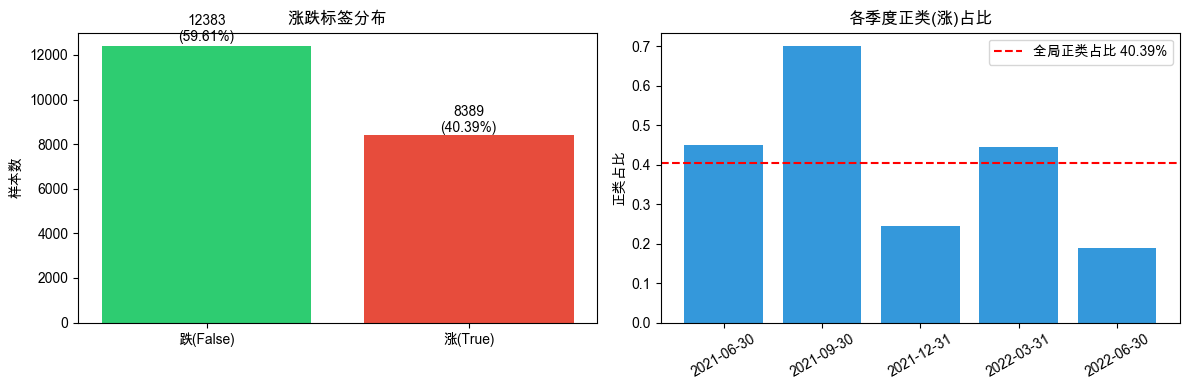

分季度分布:


,正类数,总数,正类占比
Date,,,
2021-06-30,1809,4011,0.4510
2021-09-30,2868,4098,0.6999
2021-12-31,1025,4173,0.2456
2022-03-31,1880,4228,0.4447
2022-06-30,807,4262,0.1893


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_counts = df['Y'].value_counts()
axes[0].bar(['跌(False)', '涨(True)'], y_counts.values, color=['#2ecc71', '#e74c3c'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}\n({p.get_height()/len(df):.2%})',
                     (p.get_x() + p.get_width()/2, p.get_height()*1.02), ha='center')
axes[0].set_title('涨跌标签分布')
axes[0].set_ylabel('样本数')

# 分季度标签分布
by_date = df.groupby('Date')['Y'].agg(['sum', 'count', 'mean']).rename(columns={'sum':'正类数','count':'总数','mean':'正类占比'})
axes[1].bar([d.strftime('%Y-%m-%d') for d in by_date.index], by_date['正类占比'], color='#3498db')
axes[1].axhline(df['Y'].mean(), color='red', ls='--', label=f'全局正类占比 {df["Y"].mean():.2%}')
axes[1].set_title('各季度正类(涨)占比')
axes[1].set_ylabel('正类占比')
axes[1].set_xticklabels([d.strftime('%Y-%m-%d') for d in by_date.index], rotation=30)
axes[1].legend()
plt.tight_layout()
plt.show()
print('分季度分布:')
display(by_date.round(4))

### 2.4 特征分布与偏度

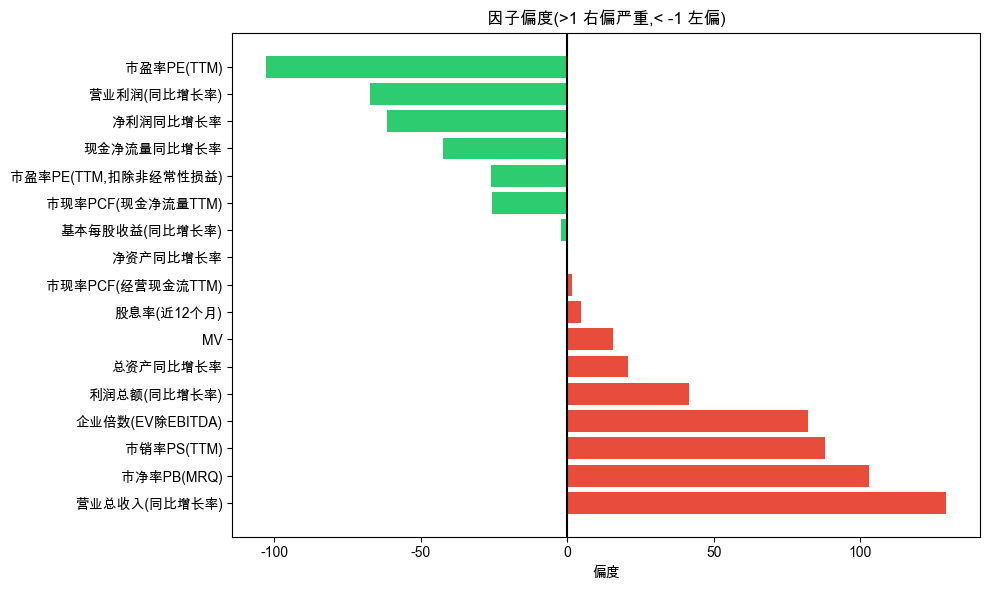

偏度最大的 5 个因子:
营业总收入(同比增长率)       129.211796
市净率PB(MRQ)         103.065372
市销率PS(TTM)          87.757880
企业倍数(EV除EBITDA)     82.123293
利润总额(同比增长率)         41.632079
dtype: float64


In [51]:
sk = df[FEATURE_COLS].skew().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if s > 1 else '#2ecc71' if s < -1 else '#95a5a6' for s in sk]
ax.barh(sk.index, sk.values, color=colors)
ax.axvline(0, color='k')
ax.set_title('因子偏度(>1 右偏严重,< -1 左偏)')
ax.set_xlabel('偏度')
plt.tight_layout()
plt.show()
print('偏度最大的 5 个因子:')
print(sk.head(5))

### 2.5 相关性分析

> **方法与口径约定(本节统一遵循)**
> - **一律采用 Spearman(秩相关),不用原始 Pearson。** 估值/增长因子强偏态、重尾,Pearson 对离群点极其敏感,少数极端样本即可主导相关系数,导致因子有效性「虚高」或被「掩盖」。Spearman 基于秩,天然抗离群点。
> - **标准化不改变相关系数,无需在算相关前做。** Pearson 对线性缩放不变,Spearman 基于秩更不受影响;标准化仅服务于模块 5.1 逻辑回归。
> - **与模块 3 的口径关系:** 本节相关性属**探索性体检**,在全量数据上用稳健方法(Spearman/rank)即可;而用于逻辑回归特征筛选/正则化的**共线性判断**(2.5.3 → 模块 5.1),最终应以**训练集**口径复核,避免泄漏。

#### 2.5.1 因子-标签相关系数(Spearman,条形图)

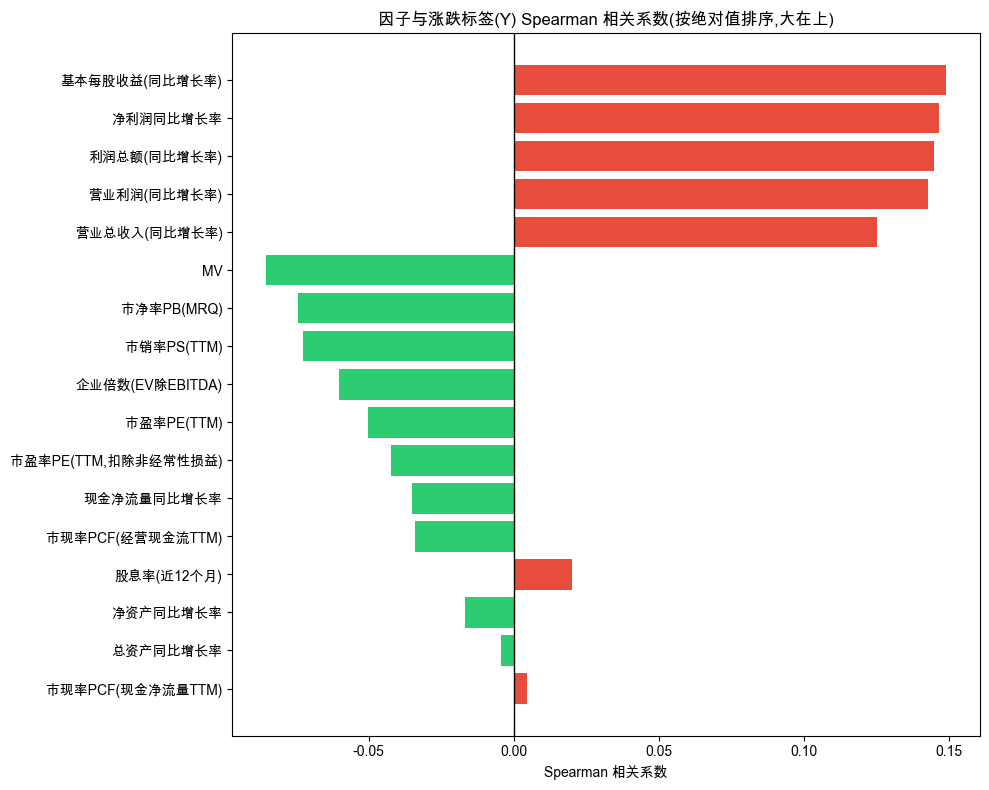

Spearman 相关系数绝对值 Top 6:
基本每股收益(同比增长率)    0.1489
净利润同比增长率         0.1464
利润总额(同比增长率)      0.1446
营业利润(同比增长率)      0.1428
营业总收入(同比增长率)     0.1250
MV              -0.0853
dtype: float64


In [52]:
# 因子与标签的 Spearman 秩相关(抗离群点,避免 Pearson 被极端值扭曲)
# 按绝对值降序:大的在前,保证 head(6) 即真正的 Top 6
corr_y = df[FEATURE_COLS].corrwith(df['Y'], method='spearman').sort_values(
    key=lambda s: s.abs(), ascending=False)

# 条形图:最大在最上面 → 画图前反转(小的先画在上面)
corr_y_plot = corr_y.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_y_plot.values]
ax.barh(corr_y_plot.index, corr_y_plot.values, color=colors)
ax.axvline(0, color='k', lw=1)
ax.set_title('因子与涨跌标签(Y) Spearman 相关系数(按绝对值排序,大在上)')
ax.set_xlabel('Spearman 相关系数')
plt.tight_layout()
plt.show()

print('Spearman 相关系数绝对值 Top 6:')
print(corr_y.head(6).round(4))

#### 2.5.2 Top 相关因子分类别箱线图(涨 vs 跌)

> **先对因子「数据本身」做截面 rank 变换再画,而非仅裁剪 y 轴。**
> 估值/增长因子重尾极端,若只设 y 轴范围,箱体(IQR)会被上千量级的离群点压成一条线,两类完全无法区分。
> 这里采用**截面 rank 变换**(按 `Date` 分组转百分位,与模块 3.2 口径一致),箱体落在 [0,1] 天然可比。

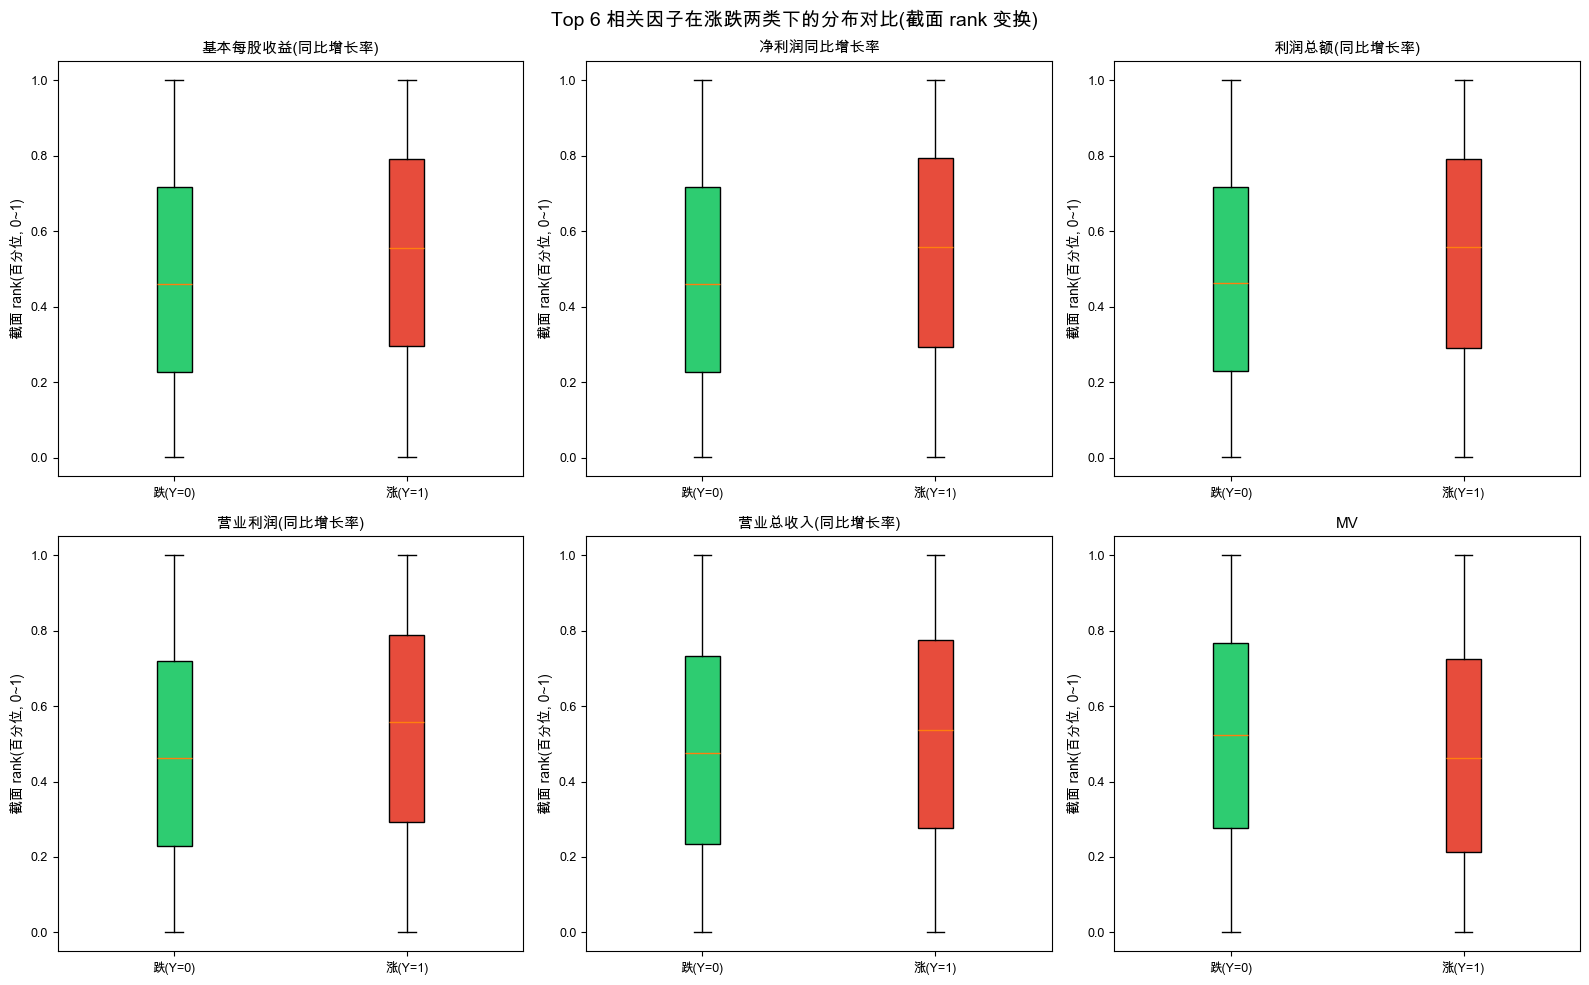

In [53]:
# 取 Spearman 相关系数绝对值 Top 6,对比 Y=0(跌) 与 Y=1(涨) 两类分布
top6 = corr_y.head(6).index.tolist()

# 截面 rank 变换:每个 Date 内部,因子取值 → 百分位排名 [0, 1]
df_rank = df[['Date','Y'] + top6].copy()
df_rank[top6] = df_rank.groupby('Date')[top6].rank(pct=True, na_option='bottom')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for ax, col in zip(axes, top6):
    data = [df_rank.loc[df_rank['Y'] == 0, col].dropna(),
            df_rank.loc[df_rank['Y'] == 1, col].dropna()]
    bp = ax.boxplot(data, patch_artist=True, labels=['跌(Y=0)', '涨(Y=1)'])
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('截面 rank(百分位, 0~1)')
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(labelsize=9)
plt.suptitle('Top 6 相关因子在涨跌两类下的分布对比(截面 rank 变换)', fontsize=14)
plt.tight_layout()
plt.show()

#### 2.5.3 因子相关矩阵热力图(共线性诊断, Spearman)

> 与 2.5.1 口径一致,使用 Spearman 相关矩阵。|corr|>0.8 视为强共线性,如多个 PE 口径、利润类增长率之间。
> 用于逻辑回归特征筛选/正则化(模块 5.1)的共线性判断,建议最终以**训练集**口径复核。

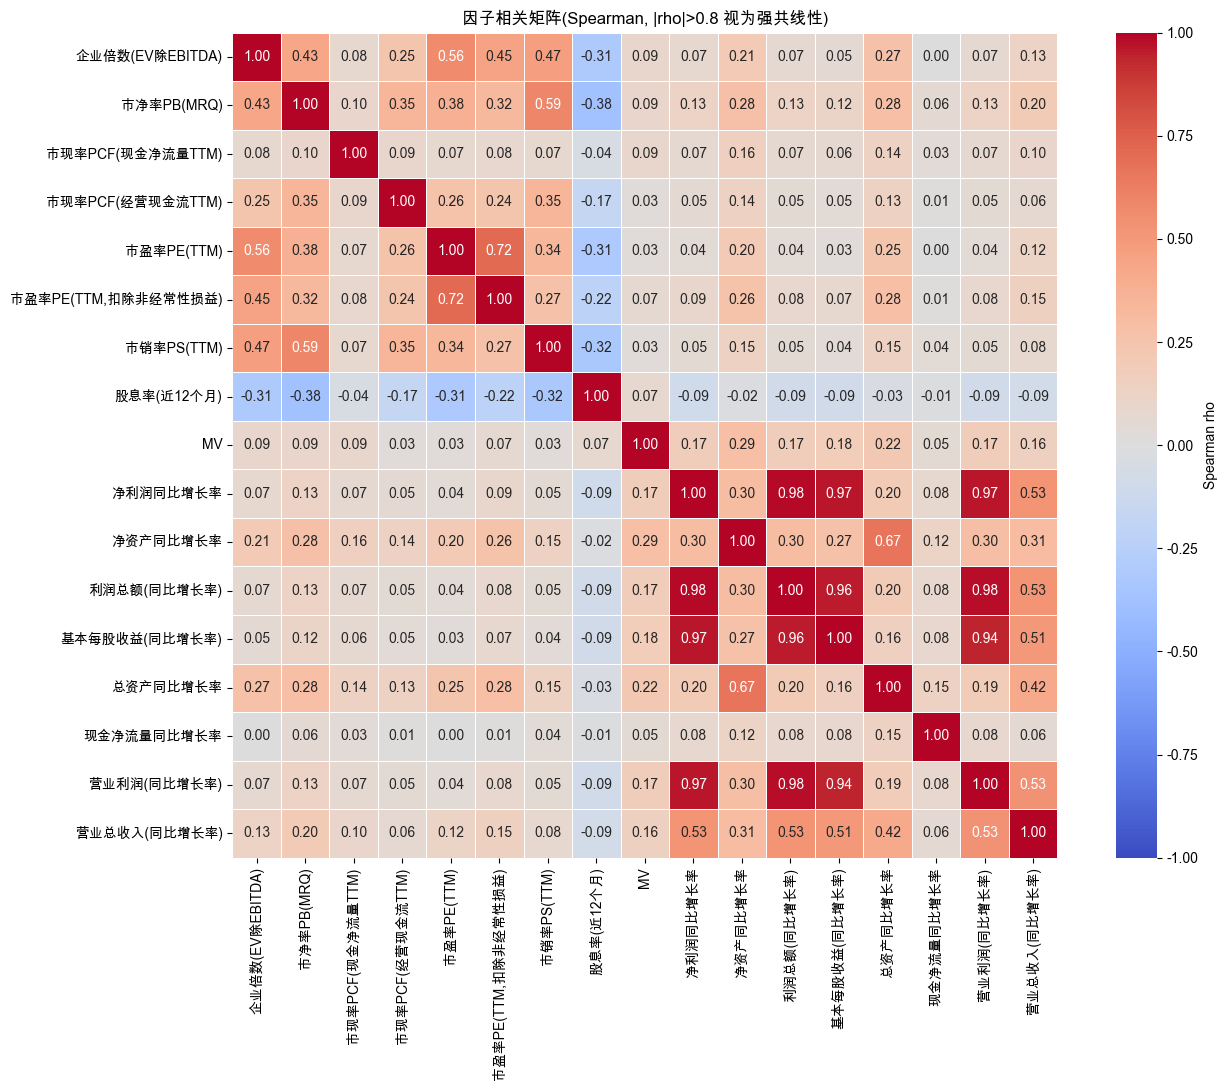

强共线性因子对(|rho|>0.8): 6


,因子A,因子B,相关系数
0,净利润同比增长率,利润总额(同比增长率),0.985
4,利润总额(同比增长率),营业利润(同比增长率),0.981
2,净利润同比增长率,营业利润(同比增长率),0.968
1,净利润同比增长率,基本每股收益(同比增长率),0.967
3,利润总额(同比增长率),基本每股收益(同比增长率),0.956
5,基本每股收益(同比增长率),营业利润(同比增长率),0.941


In [54]:
# 全部因子两两 Spearman 相关矩阵(抗离群点)
corr_mat = df[FEATURE_COLS].corr(method='spearman')
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Spearman rho'})
ax.set_title('因子相关矩阵(Spearman, |rho|>0.8 视为强共线性)')
plt.tight_layout()
plt.show()

# 标记强相关因子对
high_corr = []
cols = corr_mat.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr_mat.iloc[i, j]
        if abs(r) > 0.8:
            high_corr.append((cols[i], cols[j], r))
high_corr_df = pd.DataFrame(high_corr, columns=['因子A','因子B','相关系数']).sort_values(
    '相关系数', key=lambda s: s.abs(), ascending=False)
print(f'强共线性因子对(|rho|>0.8): {len(high_corr_df)}')
display(high_corr_df.round(3))

### 2.6 分季度标签分布检查

In [55]:
by_date = df.groupby('Date')['Y'].agg(['count','mean','sum']).rename(
    columns={'count':'样本数','mean':'正类占比','sum':'正类数'})
display(by_date.round(4))
print('→ 各期正类占比差异提示市场周期效应,需在评估时关注跨期泛化能力。')

,样本数,正类占比,正类数
Date,,,
2021-06-30,4011,0.4510,1809
2021-09-30,4098,0.6999,2868
2021-12-31,4173,0.2456,1025
2022-03-31,4228,0.4447,1880
2022-06-30,4262,0.1893,807


→ 各期正类占比差异提示市场周期效应,需在评估时关注跨期泛化能力。


## 模块 3：特征预处理(截面 rank) + 模块 4：数据集切分(TimeSeriesSplit 滚动)

### 模块 3:截面 rank 预处理
- **统一采用按 `Date` 分组的截面 rank(百分位)** 作为唯一建模输入:每个季度截面内,各因子取值 → [0,1] 百分位排名。
- 截面 rank 天然消除量纲与极端值,且**每个 `Date` 独立计算、不跨期**,因此不存在跨期泄漏(spec 模块 3.5),无需再做 winsorize / 中位数填充 / 标准化。
- 缺失值:rank 后残留 NaN 以 0.5(截面中位)填充,视为中性。

In [56]:
# 截面 rank 预处理:按 Date 分组,每个截面内因子 → 百分位 [0,1]
# 每个 Date 独立计算,天然不跨期、不泄漏(spec 模块 3.5),故可对全量一次性生成
def cross_sectional_rank(frame, cols, date_col='Date'):
    '''按 date_col 分组,对 cols 做百分位 rank(pct=True);残留 NaN 填 0.5(截面中位,中性)。'''
    ranked = frame.groupby(date_col)[cols].rank(pct=True)
    return ranked.fillna(0.5)

X_rank = cross_sectional_rank(df, FEATURE_COLS)
y_all = df['Y'].copy()  # 与 X_rank 同 index
print(f'截面 rank 特征矩阵: {X_rank.shape}  值域: [{X_rank.min().min():.3f}, {X_rank.max().max():.3f}]')
print(f'NaN 残留: {X_rank.isna().sum().sum()}')
X_rank.describe().T[['min','25%','50%','75%','max']].round(3)

截面 rank 特征矩阵: (20772, 17)  值域: [0.000, 1.000]
NaN 残留: 0


,min,25%,50%,75%,max
企业倍数(EV除EBITDA),0.0,0.25,0.5,0.75,1.0
市净率PB(MRQ),0.0,0.25,0.5,0.75,1.0
市现率PCF(现金净流量TTM),0.0,0.25,0.5,0.75,1.0
市现率PCF(经营现金流TTM),0.0,0.25,0.5,0.75,1.0
市盈率PE(TTM),0.0,0.25,0.5,0.75,1.0
"市盈率PE(TTM,扣除非经常性损益)",0.0,0.25,0.5,0.75,1.0
市销率PS(TTM),0.0,0.25,0.5,0.75,1.0
股息率(近12个月),0.0,0.25,0.5,0.75,1.0
MV,0.0,0.25,0.5,0.75,1.0
净利润同比增长率,0.0,0.25,0.5,0.75,1.0


### 模块 4:数据集切分 —— 测试集保留 + 训练/验证池 TimeSeriesSplit 滚动

| 集合 | 时点 | 用途 |
|------|------|------|
| 训练/验证池 | 前 4 期(2021-06-30 ~ 2022-03-31) | 在其上做 TimeSeriesSplit 滚动交叉验证(调参) |
| 测试集 | 末期(2022-06-30) | **最终一次性评估,调参阶段禁用** |

面板数据不能用 sklearn 的行级 `TimeSeriesSplit`(会把同一季度截面拆散、造成跨期泄漏)。
这里把 `TimeSeriesSplit` 作用在**季度序列**上,再映射回行 —— 等价于按 `Date` 的 expanding-window 滚动:

- 折1: 训练=[期0]        验证=[期1]
- 折2: 训练=[期0,1]      验证=[期2]
- 折3: 训练=[期0,1,2]    验证=[期3]

调参依据 = **各折验证指标的均值**(F1 / ROC-AUC),比单期验证更稳健。

In [57]:
dates_sorted = sorted(df['Date'].unique())
print(f'共 {len(dates_sorted)} 期:', [pd.Timestamp(d).strftime('%Y-%m-%d') for d in dates_sorted])

TRAINVAL_DATES = dates_sorted[:4]   # 前 4 期:训练/验证池
TEST_DATE      = dates_sorted[4]    # 末期:测试集(保留)

trainval_mask = df['Date'].isin(TRAINVAL_DATES)
test_mask     = df['Date'] == TEST_DATE

# 在季度序列上做 TimeSeriesSplit,映射回行 index → expanding-window 滚动折
tscv = TimeSeriesSplit(n_splits=3)
date_arr = np.array(TRAINVAL_DATES)
folds = []  # [(train_index_labels, val_index_labels), ...]
for tr_i, va_i in tscv.split(date_arr):
    tr_dates, va_dates = date_arr[tr_i], date_arr[va_i]
    tr_idx = df.index[df['Date'].isin(tr_dates)]
    va_idx = df.index[df['Date'].isin(va_dates)]
    folds.append((tr_idx, va_idx))
    print(f'  折{len(folds)}: 训练期={[pd.Timestamp(d).strftime("%m-%d") for d in tr_dates]}'
          f'({len(tr_idx)}行)  验证期={[pd.Timestamp(d).strftime("%m-%d") for d in va_dates]}({len(va_idx)}行)')

print(f'\n测试集时点: {pd.Timestamp(TEST_DATE).strftime("%Y-%m-%d")}  (仅最终对比区使用)')

共 5 期: ['2021-06-30', '2021-09-30', '2021-12-31', '2022-03-31', '2022-06-30']
  折1: 训练期=['06-30'](4011行)  验证期=['09-30'](4098行)
  折2: 训练期=['06-30', '09-30'](8109行)  验证期=['12-31'](4173行)
  折3: 训练期=['06-30', '09-30', '12-31'](12282行)  验证期=['03-31'](4228行)

测试集时点: 2022-06-30  (仅最终对比区使用)


### 切分特征矩阵(截面 rank)

- `X_trainval` / `y_trainval`:前 4 期,供 CV 滚动调参
- `X_test` / `y_test`:末期,最终评估保留
- 截面 rank 已在模块 3 一次性生成,此处仅按时点取子集(不涉及任何需在训练集拟合的统计量)

In [58]:
# 按时点取子集(rank 已生成,不需再拟合任何统计量)
X_trainval = X_rank[trainval_mask].copy()
y_trainval = y_all[trainval_mask].copy()
X_test     = X_rank[test_mask].copy()
y_test     = y_all[test_mask].copy()

print(f'训练/验证池: {X_trainval.shape}  正类占比={y_trainval.mean():.4f}')
print(f'测试集:      {X_test.shape}  正类占比={y_test.mean():.4f}')

训练/验证池: (16510, 17)  正类占比=0.4592
测试集:      (4262, 17)  正类占比=0.1893


### 模块 3.4 共线性处理(逻辑回归专用)

> **仅服务于逻辑回归**。树模型自带特征选择,无需处理。
> 依据:模块 2.5.3 强共线性(盈利增长类因子 |rho|>0.94)。
>
> **策略 B:相关簇代表因子筛选** —— 每簇仅保留与 Y 的 Spearman |corr| 最大的因子。
>
> **防泄漏**:相关矩阵与代表因子名单在**训练/验证池(前 4 期,不含测试集)**上计算一次,作为固定名单应用到测试集。

In [59]:
def select_representative_features(X_tr, y_tr, cols, corr_threshold=0.8):
    '''基于 Spearman 相关矩阵识别 |corr|>阈值 的强相关簇,每簇保留与 Y 相关性绝对值最大的因子。
    返回 (保留列, 剔除列, 簇映射, 相关矩阵)。仅在传入数据(训练/验证池)上计算。'''
    corr_mat = X_tr[cols].corr(method='spearman').fillna(0)
    corr_y = X_tr[cols].corrwith(y_tr, method='spearman').abs().fillna(0)
    order = corr_y.sort_values(ascending=False).index.tolist()
    kept, dropped, cluster_map = [], [], {}
    for c in order:
        if c in kept or c in dropped:
            continue
        kept.append(c); cluster_map[c] = []
        for other in order:
            if other == c or other in kept or other in dropped:
                continue
            if abs(corr_mat.loc[c, other]) > corr_threshold:
                dropped.append(other); cluster_map[c].append(other)
    return kept, dropped, cluster_map, corr_mat

# 仅在训练/验证池上拟合(不含测试集,防泄漏)
kept_cols, dropped_cols, cluster_map, corr_mat_tv = select_representative_features(
    X_trainval, y_trainval, FEATURE_COLS, corr_threshold=0.8)

print(f'保留代表因子: {len(kept_cols)} 个')
for rep, members in cluster_map.items():
    print(f'  ★ {rep}  ← 剔除冗余: {members}' if members else f'  · {rep}  (独立)')
print(f'\n剔除列: {dropped_cols}')

# 逻辑回归专用:去冗余后的截面 rank 特征(仅列筛选)
X_trainval_dedup = X_trainval[kept_cols].copy()
X_test_dedup     = X_test[kept_cols].copy()
print(f'\n去冗余后特征数: {len(kept_cols)}(原 {len(FEATURE_COLS)});rank 已统一量纲,无需再标准化。')

保留代表因子: 14 个
  ★ 基本每股收益(同比增长率)  ← 剔除冗余: ['净利润同比增长率', '利润总额(同比增长率)', '营业利润(同比增长率)']
  · 市净率PB(MRQ)  (独立)
  · 市销率PS(TTM)  (独立)
  · MV  (独立)
  · 企业倍数(EV除EBITDA)  (独立)
  · 营业总收入(同比增长率)  (独立)
  · 市盈率PE(TTM)  (独立)
  · 市现率PCF(经营现金流TTM)  (独立)
  · 市盈率PE(TTM,扣除非经常性损益)  (独立)
  · 净资产同比增长率  (独立)
  · 股息率(近12个月)  (独立)
  · 总资产同比增长率  (独立)
  · 现金净流量同比增长率  (独立)
  · 市现率PCF(现金净流量TTM)  (独立)

剔除列: ['净利润同比增长率', '利润总额(同比增长率)', '营业利润(同比增长率)']

去冗余后特征数: 14(原 17);rank 已统一量纲,无需再标准化。


### CV 评估函数(TimeSeriesSplit 滚动折)

- `cv_eval`:对每个折在训练部分 fit、验证部分评估,返回**各折验证指标 + 均值±std**;并在整个训练/验证池上 refit 一个模型供系数/重要性查看。
- 调参依据 = `cv_val_auc` / `cv_val_f1`(均值);测试集不在本函数出现。

In [60]:
from sklearn.base import clone

def cv_eval(estimator, folds, X, y, label=None):
    '''在滚动折上做交叉验证:每折训练部分 fit,验证部分评估。测试集不参与。
    以 numpy 数组喂入模型(规避 LightGBM 对中文/特殊字符列名的限制);
    系数/重要性在外部按 X.columns 顺序还原。
    返回 (在全部数据上 refit 的模型, 指标 dict(含各折均值))。'''
    yv = np.asarray(y)
    tr_f1s, tr_aucs, va_f1s, va_aucs, va_accs, va_pos = [], [], [], [], [], []
    for tr_idx, va_idx in folds:
        Xtr, ytr = X.loc[tr_idx].values, y.loc[tr_idx].values
        Xva, yva = X.loc[va_idx].values, y.loc[va_idx].values
        m = clone(estimator)
        m.fit(Xtr, ytr)
        p_tr, pr_tr = m.predict(Xtr), m.predict_proba(Xtr)[:, 1]
        p_va, pr_va = m.predict(Xva), m.predict_proba(Xva)[:, 1]
        tr_f1s.append(f1_score(ytr, p_tr)); tr_aucs.append(roc_auc_score(ytr, pr_tr))
        va_f1s.append(f1_score(yva, p_va)); va_aucs.append(roc_auc_score(yva, pr_va))
        va_accs.append(accuracy_score(yva, p_va)); va_pos.append(float(np.mean(p_va)))
    full = clone(estimator).fit(X.values, yv)  # 全池 refit,供系数/重要性查看
    metrics = {
        'label': label or estimator.__class__.__name__,
        'cv_tr_f1': np.mean(tr_f1s), 'cv_tr_auc': np.mean(tr_aucs),
        'cv_val_f1': np.mean(va_f1s), 'cv_val_f1_std': np.std(va_f1s),
        'cv_val_auc': np.mean(va_aucs), 'cv_val_auc_std': np.std(va_aucs),
        'cv_val_acc': np.mean(va_accs), 'pred_pos_ratio': np.mean(va_pos),
        'fold_val_aucs': [round(a, 4) for a in va_aucs],
    }
    return full, metrics

def log_experiment(experiments, model, params, metrics):
    row = {'model': metrics['label'], **params,
           'cv_val_f1': metrics['cv_val_f1'], 'cv_val_auc': metrics['cv_val_auc'],
           'cv_val_auc_std': metrics['cv_val_auc_std'], 'cv_tr_auc': metrics['cv_tr_auc']}
    experiments.append(row)
    return row

experiments = []
print('CV 评估函数与实验日志就绪。')

CV 评估函数与实验日志就绪。


## 模块 5：模型训练与调参

> 测试集不在本模块使用。调参依据 = **TimeSeriesSplit 滚动折的验证均值**(cv_val_f1 / cv_val_auc)。
> 单模型迭代:CV 评估 → 调超参 → 记录 → 选最优冻结。
>
> **输入约定**:逻辑回归用去冗余截面 rank(`X_trainval_dedup`);树模型用全量截面 rank(`X_trainval`)。

[基线 L1] CV val_auc=0.5569±0.1025  val_f1=0.4978  各折AUC=[np.float64(0.4751), np.float64(0.7014), np.float64(0.4941)]


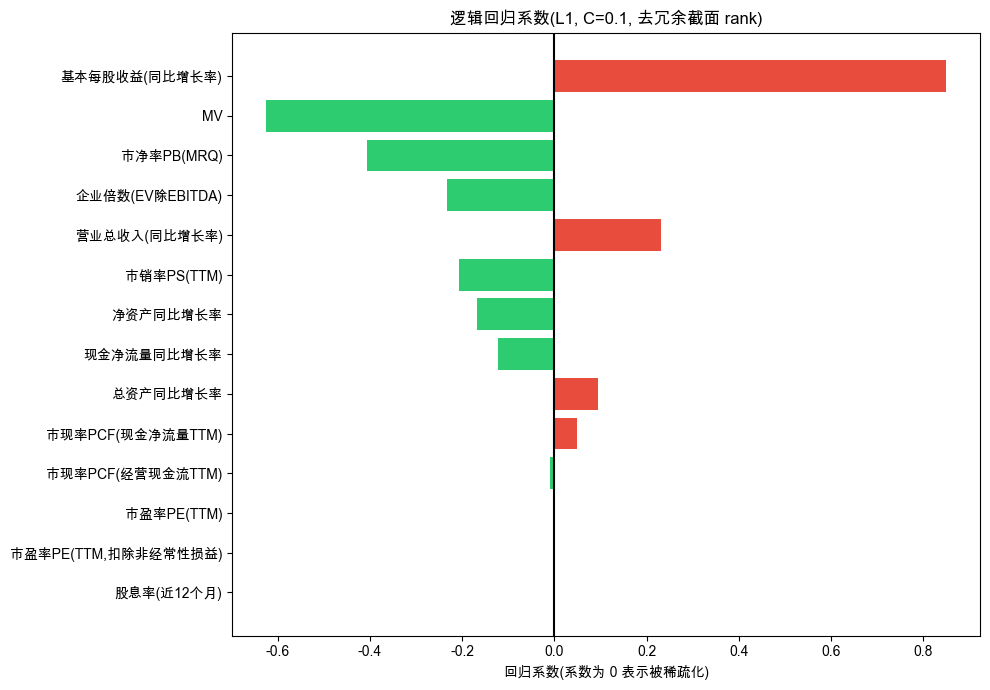


L1 稀疏化: 11/14 个因子系数非零
基本每股收益(同比增长率)       0.8491
MV                 -0.6243
市净率PB(MRQ)         -0.4054
企业倍数(EV除EBITDA)    -0.2319
营业总收入(同比增长率)        0.2313
市销率PS(TTM)         -0.2070
净资产同比增长率           -0.1674
现金净流量同比增长率         -0.1214
总资产同比增长率            0.0948
市现率PCF(现金净流量TTM)    0.0489
市现率PCF(经营现金流TTM)   -0.0091
dtype: float64


In [62]:
# 基线:L1 正则化 + 去冗余截面 rank(应对盈利增长类因子强共线性)
lr0 = LogisticRegression(max_iter=2000, class_weight='balanced',
                         penalty='l1', solver='saga', C=0.1, random_state=SEED)
lr0_full, m = cv_eval(lr0, folds, X_trainval_dedup, y_trainval, label='LR_default_L1')
print(f'[基线 L1] CV val_auc={m["cv_val_auc"]:.4f}±{m["cv_val_auc_std"]:.4f}  '
      f'val_f1={m["cv_val_f1"]:.4f}  各折AUC={m["fold_val_aucs"]}')
log_experiment(experiments, lr0, {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}, m);

# 全池 refit 模型的系数(L1 稀疏化)
coef = pd.Series(lr0_full.coef_[0], index=X_trainval_dedup.columns).sort_values(
    key=lambda s: s.abs(), ascending=False)
coef_plot = coef.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in coef_plot.values]
ax.barh(coef_plot.index, coef_plot.values, color=colors)
ax.axvline(0, color='k')
ax.set_title('逻辑回归系数(L1, C=0.1, 去冗余截面 rank)')
ax.set_xlabel('回归系数(系数为 0 表示被稀疏化)')
plt.tight_layout(); plt.show()
nz = coef[coef != 0]
print(f'\nL1 稀疏化: {len(nz)}/{len(coef)} 个因子系数非零')
print(nz.round(4))

#### 逻辑回归调参单元(可反复运行)

> 默认 L1 + 去冗余数据。主调 `C`(`C` 越小越稀疏),若需保留全部因子可换回 L2 作为对照。

In [18]:
# >>>>>> 调参区:修改下方参数后反复运行此 cell <<<<<<
C = 0.01
penalty = 'l1'
solver = 'saga'

lr = LogisticRegression(max_iter=2000, class_weight='balanced',
                        C=C, penalty=penalty, solver=solver, random_state=SEED)
_, m = cv_eval(lr, folds, X_trainval_dedup, y_trainval,
               label=f'LR(C={C}, penalty={penalty}, dedup)')
print(f'CV val_auc={m["cv_val_auc"]:.4f}±{m["cv_val_auc_std"]:.4f}  '
      f'val_f1={m["cv_val_f1"]:.4f}  各折AUC={m["fold_val_aucs"]}')
log_experiment(experiments, lr, {'C': C, 'penalty': penalty, 'solver': solver}, m);
print(f'累计实验: {len(experiments)} 条')

CV val_auc=0.5347±0.1084  val_f1=0.4869  各折AUC=[np.float64(0.4629), np.float64(0.6878), np.float64(0.4533)]
累计实验: 2 条


### 5.2 决策树

In [19]:
# 基线(全量截面 rank,无需标准化)
dt0 = DecisionTreeClassifier(random_state=SEED, class_weight='balanced',
                             max_depth=5, min_samples_leaf=50)
_, m = cv_eval(dt0, folds, X_trainval, y_trainval, label='DT_default')
print(f'[基线] CV val_auc={m["cv_val_auc"]:.4f}±{m["cv_val_auc_std"]:.4f}  '
      f'val_f1={m["cv_val_f1"]:.4f}  各折AUC={m["fold_val_aucs"]}')
log_experiment(experiments, dt0, {'max_depth': 5, 'min_samples_leaf': 50}, m);

[基线] CV val_auc=0.5297±0.0528  val_f1=0.4988  各折AUC=[np.float64(0.4889), np.float64(0.6043), np.float64(0.496)]


#### 决策树调参单元(可反复运行)

In [20]:
# >>>>>> 调参区:修改下方参数后反复运行此 cell <<<<<<
max_depth = 6
min_samples_leaf = 30
min_samples_split = 100

dt = DecisionTreeClassifier(random_state=SEED, class_weight='balanced',
                            max_depth=max_depth, min_samples_leaf=min_samples_leaf,
                            min_samples_split=min_samples_split)
_, m = cv_eval(dt, folds, X_trainval, y_trainval,
               label=f'DT(depth={max_depth},leaf={min_samples_leaf})')
print(f'CV val_auc={m["cv_val_auc"]:.4f}±{m["cv_val_auc_std"]:.4f}  '
      f'val_f1={m["cv_val_f1"]:.4f}  各折AUC={m["fold_val_aucs"]}')
log_experiment(experiments, dt,
               {'max_depth': max_depth, 'min_samples_leaf': min_samples_leaf,
                'min_samples_split': min_samples_split}, m);
print(f'累计实验: {len(experiments)} 条')

CV val_auc=0.5268±0.0471  val_f1=0.5011  各折AUC=[np.float64(0.4893), np.float64(0.5932), np.float64(0.4979)]
累计实验: 4 条


### 5.3 随机森林

In [21]:
rf0 = RandomForestClassifier(random_state=SEED, class_weight='balanced',
                             n_estimators=200, max_depth=8, min_samples_leaf=30, n_jobs=-1)
_, m = cv_eval(rf0, folds, X_trainval, y_trainval, label='RF_default')
print(f'[基线] CV val_auc={m["cv_val_auc"]:.4f}±{m["cv_val_auc_std"]:.4f}  '
      f'val_f1={m["cv_val_f1"]:.4f}  各折AUC={m["fold_val_aucs"]}')
log_experiment(experiments, rf0, {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 30}, m);

[基线] CV val_auc=0.5355±0.0691  val_f1=0.4789  各折AUC=[np.float64(0.4718), np.float64(0.6315), np.float64(0.5033)]


#### 随机森林调参单元(可反复运行)

In [22]:
# >>>>>> 调参区:修改下方参数后反复运行此 cell <<<<<<
n_estimators = 300
max_depth = 10
min_samples_leaf = 20
max_features = 'sqrt'

rf = RandomForestClassifier(random_state=SEED, class_weight='balanced',
                            n_estimators=n_estimators, max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            max_features=max_features, n_jobs=-1)
_, m = cv_eval(rf, folds, X_trainval, y_trainval,
               label=f'RF(n={n_estimators},d={max_depth})')
print(f'CV val_auc={m["cv_val_auc"]:.4f}±{m["cv_val_auc_std"]:.4f}  '
      f'val_f1={m["cv_val_f1"]:.4f}  各折AUC={m["fold_val_aucs"]}')
log_experiment(experiments, rf,
               {'n_estimators': n_estimators, 'max_depth': max_depth,
                'min_samples_leaf': min_samples_leaf, 'max_features': max_features}, m);
print(f'累计实验: {len(experiments)} 条')

CV val_auc=0.5364±0.0684  val_f1=0.4763  各折AUC=[np.float64(0.4756), np.float64(0.632), np.float64(0.5017)]
累计实验: 6 条


### 5.4 LightGBM(梯度提升树)

> XGBoost 与 LightGBM 二选一,此处用 LightGBM(训练快)。接口等价,可按需替换。
> 不平衡处理:`scale_pos_weight ≈ 负类数/正类数`。

In [23]:
# scale_pos_weight 按训练/验证池计算
neg_tv = int((y_trainval == 0).sum()); pos_tv = int((y_trainval == 1).sum())
spw = neg_tv / pos_tv
print(f'训练/验证池 负类={neg_tv} 正类={pos_tv}  scale_pos_weight≈{spw:.3f}')

lgb0 = LGBMClassifier(random_state=SEED, scale_pos_weight=spw,
                      learning_rate=0.05, n_estimators=300, max_depth=6, num_leaves=31,
                      subsample=0.8, colsample_bytree=0.8,
                      reg_alpha=0.1, reg_lambda=0.1, verbose=-1)
_, m = cv_eval(lgb0, folds, X_trainval, y_trainval, label='LGBM_default')
print(f'[基线] CV val_auc={m["cv_val_auc"]:.4f}±{m["cv_val_auc_std"]:.4f}  '
      f'val_f1={m["cv_val_f1"]:.4f}  各折AUC={m["fold_val_aucs"]}')
log_experiment(experiments, lgb0,
               {'learning_rate': 0.05, 'n_estimators': 300, 'max_depth': 6,
                'num_leaves': 31, 'scale_pos_weight': round(spw, 3)}, m);

训练/验证池 负类=8928 正类=7582  scale_pos_weight≈1.178


[基线] CV val_auc=0.5319±0.0677  val_f1=0.4652  各折AUC=[np.float64(0.4714), np.float64(0.6264), np.float64(0.4977)]


#### LightGBM 调参单元(可反复运行)

In [24]:
# >>>>>> 调参区:修改下方参数后反复运行此 cell <<<<<<
learning_rate = 0.03
n_estimators = 500
max_depth = 5
num_leaves = 24
subsample = 0.8
colsample_bytree = 0.7
reg_alpha = 0.1
reg_lambda = 1.0

lgb = LGBMClassifier(random_state=SEED, scale_pos_weight=spw,
                     learning_rate=learning_rate, n_estimators=n_estimators,
                     max_depth=max_depth, num_leaves=num_leaves,
                     subsample=subsample, colsample_bytree=colsample_bytree,
                     reg_alpha=reg_alpha, reg_lambda=reg_lambda, verbose=-1)
_, m = cv_eval(lgb, folds, X_trainval, y_trainval,
               label=f'LGBM(lr={learning_rate},n={n_estimators},d={max_depth})')
print(f'CV val_auc={m["cv_val_auc"]:.4f}±{m["cv_val_auc_std"]:.4f}  '
      f'val_f1={m["cv_val_f1"]:.4f}  各折AUC={m["fold_val_aucs"]}')
log_experiment(experiments, lgb,
               {'learning_rate': learning_rate, 'n_estimators': n_estimators,
                'max_depth': max_depth, 'num_leaves': num_leaves,
                'subsample': subsample, 'colsample_bytree': colsample_bytree,
                'reg_alpha': reg_alpha, 'reg_lambda': reg_lambda}, m);
print(f'累计实验: {len(experiments)} 条')

CV val_auc=0.5347±0.0681  val_f1=0.4703  各折AUC=[np.float64(0.4747), np.float64(0.63), np.float64(0.4994)]
累计实验: 8 条


### 实验日志

In [25]:
exp_df = pd.DataFrame(experiments)
print(f'共 {len(exp_df)} 次实验(按 cv_val_auc 降序)')
display(exp_df.sort_values('cv_val_auc', ascending=False))

共 8 次实验(按 cv_val_auc 降序)


,model,C,penalty,solver,cv_val_f1,cv_val_auc,cv_val_auc_std,cv_tr_auc,max_depth,min_samples_leaf,min_samples_split,n_estimators,max_features,learning_rate,num_leaves,scale_pos_weight,subsample,colsample_bytree,reg_alpha,reg_lambda
0,LR_default_L1,0.10,l1,saga,0.497759,0.556864,0.102465,0.641962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"RF(n=300,d=10)",NaN,NaN,NaN,0.476300,0.536414,0.068425,0.822295,10.0,20.0,NaN,300.0,sqrt,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RF_default,NaN,NaN,NaN,0.478907,0.535542,0.069086,0.762512,8.0,30.0,NaN,200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,"LGBM(lr=0.03,n=500,d=5)",NaN,NaN,NaN,0.470251,0.534689,0.068141,0.887477,5.0,NaN,NaN,500.0,NaN,0.03,24.0,NaN,0.8,0.7,0.1,1.0
1,"LR(C=0.01, penalty=l1, dedup)",0.01,l1,saga,0.486893,0.534685,0.108356,0.627250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,LGBM_default,NaN,NaN,NaN,0.465192,0.531851,0.067693,0.938896,6.0,NaN,NaN,300.0,NaN,0.05,31.0,1.178,NaN,NaN,NaN,NaN
2,DT_default,NaN,NaN,NaN,0.498782,0.529736,0.052811,0.671941,5.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"DT(depth=6,leaf=30)",NaN,NaN,NaN,0.501086,0.526800,0.047115,0.691922,6.0,30.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 模块 6：模型评估与对比(最终对比区,仅运行一次)

> **前置条件**:所有模型已在模块 5 用 CV 完成调参、超参冻结。
> 本区在**整个训练/验证池(前 4 期)**上 refit 各最优模型,用**保留的测试集(末期)**做一次性评估。
> 输入沿用模块 3 的截面 rank(逻辑回归用去冗余版)。

In [26]:
# 各模型最优配置(与模块 5 调参结论对齐)
final_models = {
    '逻辑回归': LogisticRegression(max_iter=2000, class_weight='balanced',
                                   C=0.1, penalty='l1', solver='saga', random_state=SEED),
    '决策树':   DecisionTreeClassifier(random_state=SEED, class_weight='balanced',
                                   max_depth=5, min_samples_leaf=50),
    '随机森林': RandomForestClassifier(random_state=SEED, class_weight='balanced',
                                   n_estimators=200, max_depth=8, min_samples_leaf=30, n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=SEED, scale_pos_weight=spw,
                                   learning_rate=0.05, n_estimators=300, max_depth=6, num_leaves=31,
                                   subsample=0.8, colsample_bytree=0.8,
                                   reg_alpha=0.1, reg_lambda=0.1, verbose=-1),
}
# 逻辑回归使用去冗余截面 rank,其余用全量截面 rank
need_scale_dedup = {'逻辑回归'}

final_results = []
final_fit_models = {}
for name, mdl in final_models.items():
    Xtv, Xte = (X_trainval_dedup, X_test_dedup) if name in need_scale_dedup else (X_trainval, X_test)
    full, cvm = cv_eval(mdl, folds, Xtv, y_trainval, name)  # CV 验证均值 + 全池 refit
    final_fit_models[name] = full
    p_te, pr_te = full.predict(Xte.values), full.predict_proba(Xte.values)[:, 1]
    p_tv, pr_tv = full.predict(Xtv.values), full.predict_proba(Xtv.values)[:, 1]
    final_results.append({
        '模型': name,
        'tr_acc': accuracy_score(y_trainval, p_tv), 'tr_f1': f1_score(y_trainval, p_tv),
        'tr_auc': roc_auc_score(y_trainval, pr_tv),
        'cv_val_f1': cvm['cv_val_f1'], 'cv_val_auc': cvm['cv_val_auc'],
        'test_acc': accuracy_score(y_test, p_te), 'test_prec': precision_score(y_test, p_te),
        'test_rec': recall_score(y_test, p_te), 'test_f1': f1_score(y_test, p_te),
        'test_auc': roc_auc_score(y_test, pr_te),
    })

base_acc = max(y_test.mean(), 1 - y_test.mean())
print(f'测试集样本数: {len(y_test)}  正类占比: {y_test.mean():.4f}  基准准确率: {base_acc:.4f}')
print(f'(逻辑回归使用去冗余截面 rank,特征数 {len(kept_cols)})\n')
final_df = pd.DataFrame(final_results)
num_cols = [c for c in final_df.columns if c != '模型']
display(final_df.style.format({c: '{:.4f}' for c in num_cols}))

测试集样本数: 4262  正类占比: 0.1893  基准准确率: 0.8107
(逻辑回归使用去冗余截面 rank,特征数 14)



,模型,tr_acc,tr_f1,tr_auc,cv_val_f1,cv_val_auc,test_acc,test_prec,test_rec,test_f1,test_auc
0,逻辑回归,0.5784,0.5524,0.6061,0.4978,0.5569,0.5615,0.2412,0.6134,0.3463,0.6195
1,决策树,0.5891,0.5501,0.6256,0.4988,0.5297,0.5626,0.2405,0.6072,0.3446,0.5912
2,随机森林,0.6550,0.6388,0.7187,0.4789,0.5355,0.5373,0.2419,0.6766,0.3564,0.6211
3,LightGBM,0.7749,0.7615,0.8671,0.4652,0.5319,0.5235,0.2258,0.6245,0.3317,0.5951


### 6.2 ROC 曲线对比

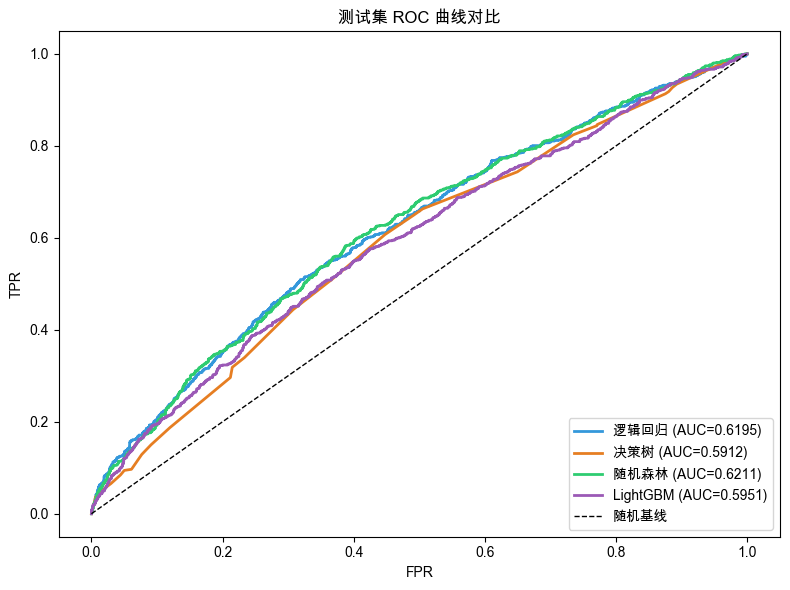

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']
for (name, mdl), color in zip(final_fit_models.items(), colors):
    Xte = X_test_dedup if name in need_scale_dedup else X_test
    proba = mdl.predict_proba(Xte.values)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='随机基线')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('测试集 ROC 曲线对比'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

### 6.3 混淆矩阵

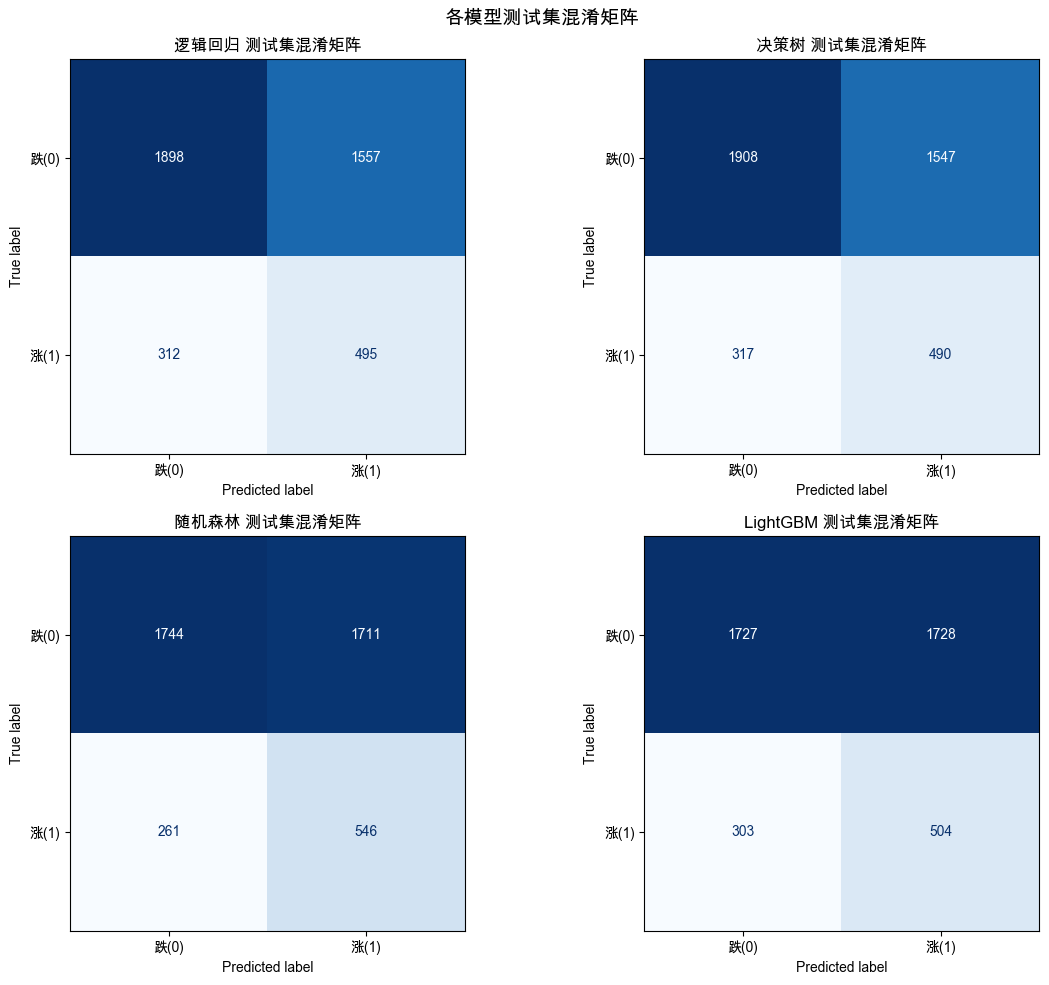

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, name in zip(axes.flatten(), final_fit_models.keys()):
    mdl = final_fit_models[name]
    Xte = X_test_dedup if name in need_scale_dedup else X_test
    y_pred = mdl.predict(Xte.values)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['跌(0)', '涨(1)']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} 测试集混淆矩阵')
plt.suptitle('各模型测试集混淆矩阵', fontsize=14)
plt.tight_layout(); plt.show()

### 6.4 特征重要性对比

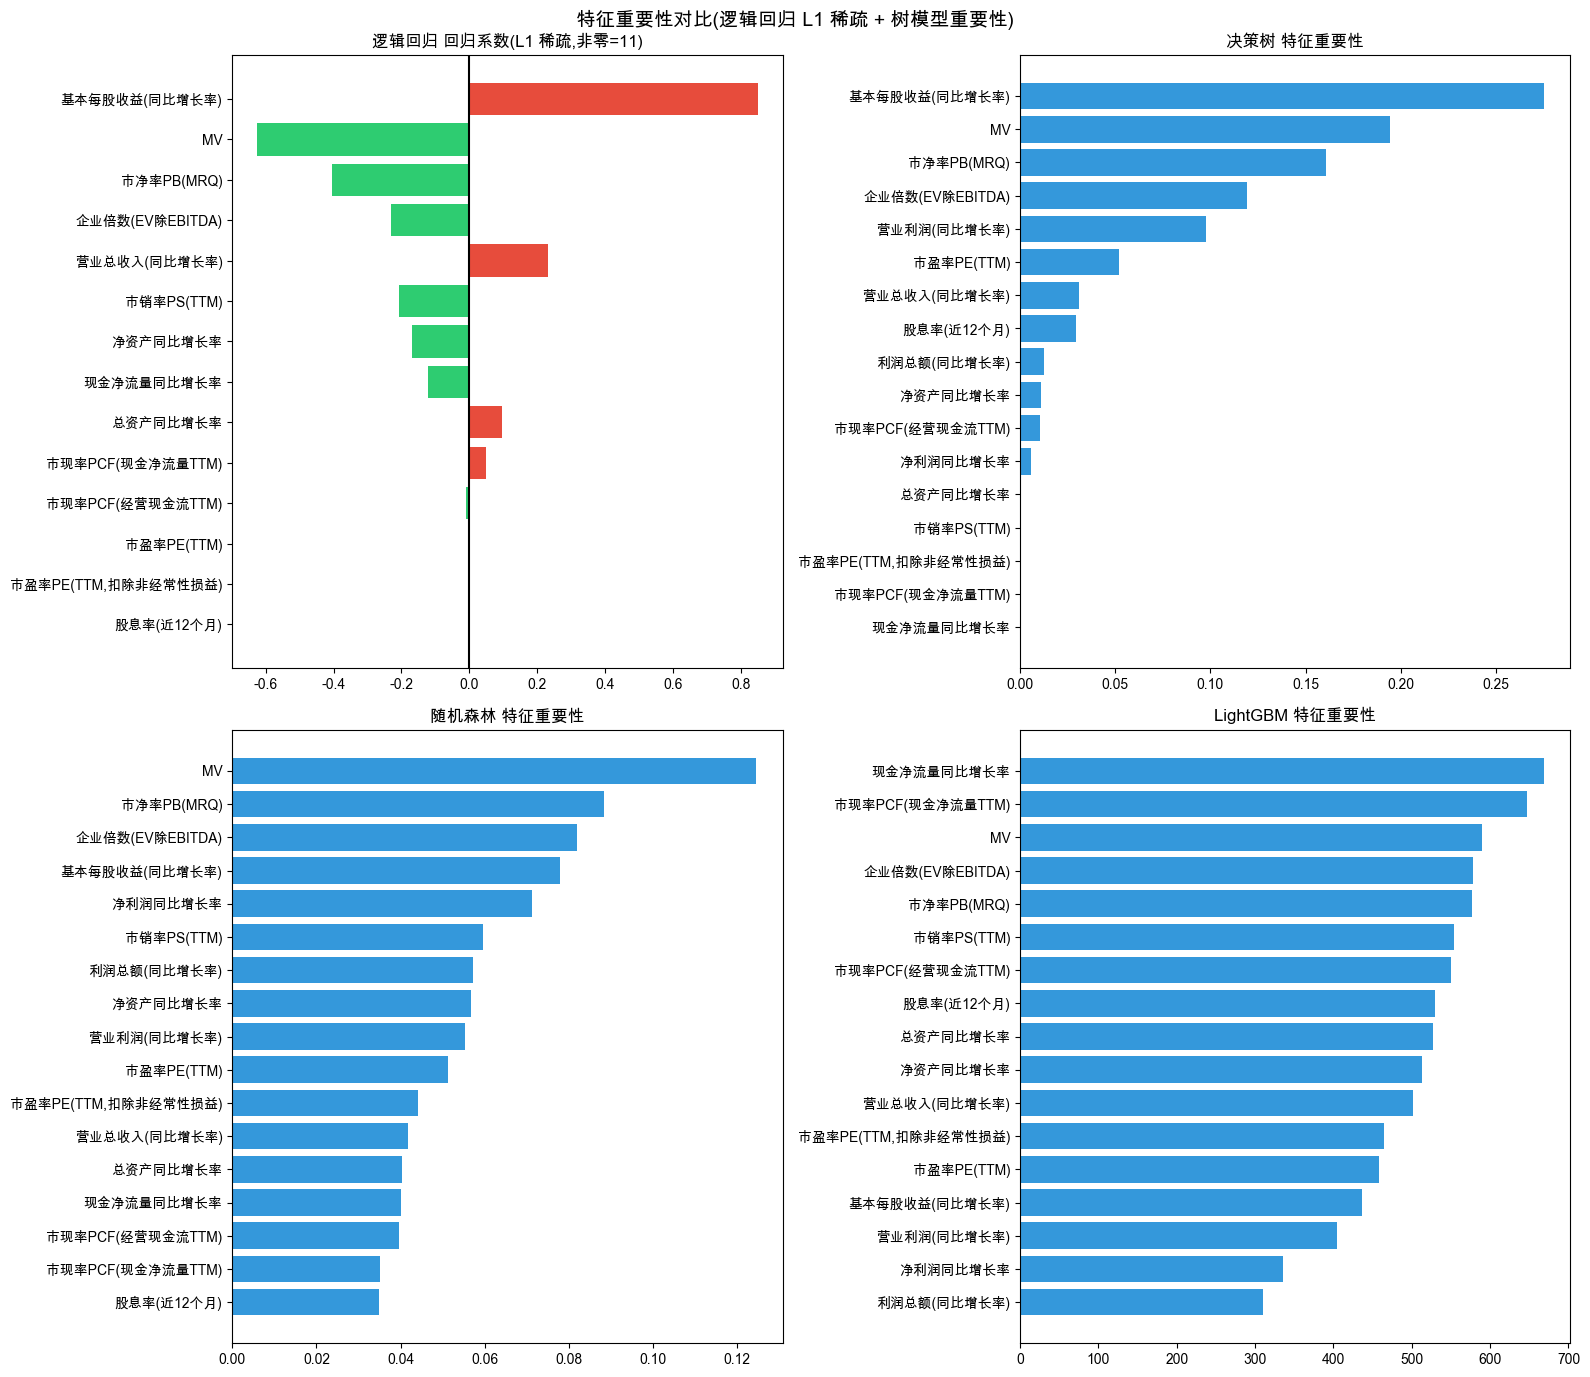

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 逻辑回归(去冗余截面 rank,体现 L1 稀疏化);系数按 refit 时的列顺序还原
lr_m = final_fit_models['逻辑回归']
coef = pd.Series(lr_m.coef_[0], index=X_trainval_dedup.columns).sort_values(key=lambda s: s.abs(), ascending=False)
coef_plot = coef.iloc[::-1]
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in coef_plot.values]
axes[0, 0].barh(coef_plot.index, coef_plot.values, color=colors)
axes[0, 0].axvline(0, color='k')
axes[0, 0].set_title(f'逻辑回归 回归系数(L1 稀疏,非零={int((coef != 0).sum())})')

# 树模型(全量截面 rank,17 因子);feature_importances_ 按 X_trainval 列顺序还原
for ax, name in zip([axes[0, 1], axes[1, 0], axes[1, 1]], ['决策树', '随机森林', 'LightGBM']):
    mdl = final_fit_models[name]
    imp = pd.Series(mdl.feature_importances_, index=X_trainval.columns)
    imp = imp.sort_values(ascending=True).tail(17)
    ax.barh(imp.index, imp.values, color='#3498db')
    ax.set_title(f'{name} 特征重要性')
plt.suptitle('特征重要性对比(逻辑回归 L1 稀疏 + 树模型重要性)', fontsize=14)
plt.tight_layout(); plt.show()

### 6.5 过拟合检查(训练池 vs CV 验证 vs 测试集)

In [30]:
cols_show = ['模型', 'tr_f1', 'tr_auc', 'cv_val_f1', 'cv_val_auc', 'test_f1', 'test_auc']
display(final_df[cols_show].style.format({c: '{:.4f}' for c in cols_show[1:]}))

print('\n过拟合诊断(训练池 vs CV 验证 vs 测试):')
for _, row in final_df.iterrows():
    name = row['模型']
    gap_auc = row['tr_auc'] - row['test_auc']
    gap_f1  = row['tr_f1']  - row['test_f1']
    cv_gap_auc = row['cv_val_auc'] - row['test_auc']
    note = ''
    if gap_auc > 0.05 or gap_f1 > 0.1:
        note += ' ⚠ 训练/测试差距大,存在过拟合风险'
    if cv_gap_auc > 0.05:
        note += ' ⚠ CV验证/测试差距大,可能过度调参或期间漂移'
    if not note:
        note = ' ✓ 泛化良好'
    print(f'  {name}: tr_auc-test_auc={gap_auc:+.4f}  tr_f1-test_f1={gap_f1:+.4f}  cv_val_auc-test_auc={cv_gap_auc:+.4f}{note}')

,模型,tr_f1,tr_auc,cv_val_f1,cv_val_auc,test_f1,test_auc
0,逻辑回归,0.5524,0.6061,0.4978,0.5569,0.3463,0.6195
1,决策树,0.5501,0.6256,0.4988,0.5297,0.3446,0.5912
2,随机森林,0.6388,0.7187,0.4789,0.5355,0.3564,0.6211
3,LightGBM,0.7615,0.8671,0.4652,0.5319,0.3317,0.5951



过拟合诊断(训练池 vs CV 验证 vs 测试):
  逻辑回归: tr_auc-test_auc=-0.0135  tr_f1-test_f1=+0.2061  cv_val_auc-test_auc=-0.0627 ⚠ 训练/测试差距大,存在过拟合风险
  决策树: tr_auc-test_auc=+0.0344  tr_f1-test_f1=+0.2055  cv_val_auc-test_auc=-0.0615 ⚠ 训练/测试差距大,存在过拟合风险
  随机森林: tr_auc-test_auc=+0.0976  tr_f1-test_f1=+0.2824  cv_val_auc-test_auc=-0.0856 ⚠ 训练/测试差距大,存在过拟合风险
  LightGBM: tr_auc-test_auc=+0.2720  tr_f1-test_f1=+0.4298  cv_val_auc-test_auc=-0.0632 ⚠ 训练/测试差距大,存在过拟合风险


## 结论

请根据上方结果回答:
1. **最优模型**:验证集 AUC/F1 最高且测试集表现稳健的模型是?
2. **是否显著优于基准**:测试集 AUC 是否 > 0.5(随机)且 F1/Accuracy 是否 > {基准}?
3. **关键驱动因子**:从特征重要性对比图中,哪些因子被多个模型一致认为是 Top?
4. **过拟合状况**:训练/验证/测试三集差距是否可接受?

如需进一步调优,请回到模块 5 对应模型的调参单元,继续迭代。